In [74]:
# ================================================================
# Quick visual: N random test profiles – flux & signed % error
# ================================================================
import sys, json, random, time
from pathlib import Path
import torch, numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

plt.style.use('../jupyter_notebooks/science.mplstyle')

ROOT = Path.cwd()
while not (ROOT / "src").is_dir():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Could not find a 'src' directory above this notebook.")
    ROOT = ROOT.parent
SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

# ---------- project paths ----------------------------------------
CFG   = ROOT / "inputs" / "model_input_params.jsonc"
MODEL = ROOT / "data" / "model" / "best_model.pt"
TEST  = ROOT / "data" / "model" / "test_set_info.json"
DATA  = ROOT / "data" / "normalized_profiles"
META  = DATA / "normalization_metadata.json"

# ---------- internal imports -------------------------------------
from utils      import load_config
from dataset    import AtmosphericDataset, create_multi_source_collate_fn
from model      import create_prediction_model
from normalizer import DataNormalizer

# ---------- set‑up objects ---------------------------------------
cfg    = load_config(CFG)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")          # ← device info

ds = AtmosphericDataset(
    DATA,
    cfg["input_variables"],
    cfg["target_variables"],
    cfg.get("global_variables", []),
    cfg["sequence_types"],
    cfg["sequence_lengths"],
    cfg["output_seq_type"],
    validate_profiles=False,
)

print(cfg["target_variables"])
print(cfg["input_variables"])


Running on: cpu
['albedo']
['wav']


Inference time for 1 profiles: 13.7 ms


/opt/homebrew/Caskroom/miniforge/base/envs/nn/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Text(0, 0.5, 'Signed Percent Error')

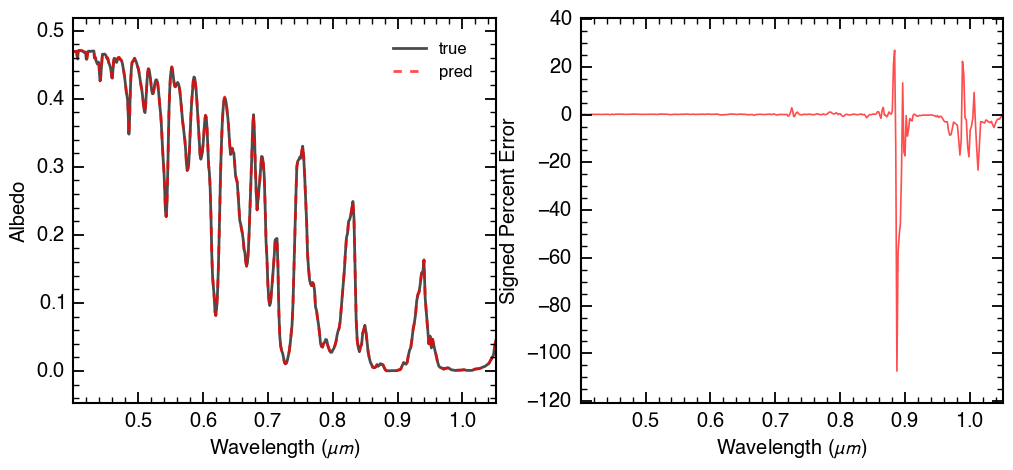

In [75]:
num_samples = 1
test_ids = json.load(TEST.open())["test_indices"]
batch    = DataLoader(
              Subset(ds, random.sample(test_ids, num_samples)),
              batch_size=num_samples,
              collate_fn=create_multi_source_collate_fn()).__iter__().__next__()

model = create_prediction_model(cfg, device=device)
model.load_state_dict(torch.load(MODEL, map_location=device)["state_dict"])
model.eval()

input_str  = cfg["input_variables"][0]
target_str = cfg["target_variables"][0]


meta = json.load(META.open())

# ---------- inference (timed) ------------------------------------
x, y_true = batch
x = {k: v.to(device) for k, v in x.items()}

t0 = time.perf_counter()
with torch.no_grad():
    pred = model(x).cpu()
infer_ms = (time.perf_counter() - t0) * 1e3
print(f"Inference time for {num_samples} profiles: {infer_ms:.1f} ms")


# ---------- denormalise & detach --------------------------------
x0   = DataNormalizer.denormalize(x["sequence1"][:,:,0],  meta, input_str).detach().numpy()
true = DataNormalizer.denormalize(y_true[:,:,0],         meta, target_str).detach().numpy()
y0 = DataNormalizer.denormalize(pred[:,:,0],         meta, target_str).detach().numpy()

# ---------- plotting --------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for i in range(num_samples):
    ax[0].plot(x0[i], true[i], color='black', linewidth=2, alpha=.7, label="true" if i==0 else None)
    ax[0].plot(x0[i], y0[i], color='red',   linestyle='--', linewidth=2, alpha=.7, label="pred" if i==0 else None)

    err = 100 * (y0[i] - true[i]) / np.maximum(np.abs(true[i]), 1e-5)      # signed error
    ax[1].plot(x0[i], err, 'r-', linewidth=1.2, alpha=.7)

# cosmetics
ax[0].set_xlabel(r"Wavelength ($\mu m$)")
ax[0].set_ylabel("Albedo")
ax[0].legend()
#ax[0].set_yscale('log')
#ax[0].set_xscale('log')
#ax[0].set_xlim(0.5, 50)
#ax[0].set_ylim(1e7, 1e14)


ax[1].set_xlabel(r"Wavelength ($\mu m$)")
ax[1].set_ylabel('Signed Percent Error')
#ax[1].set_yscale('symlog')


